© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

In [ ]:
!pip install wandb --upgrade -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 104.1 MB/s eta 0:00:00


In [ ]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: angelo-grillo123 (angelo-grillo123-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
!pip install gitignore_parser==0.1.12 "jsonargparse[signatures]==4.38" matplotlib==3.10.1 timm==1.0.15 wandb==0.19.10 lightning==2.5.1.post0 transformers==4.56.1 scipy==1.15.2 fvcore==0.1.5.post20221221 torchmetrics==1.7.1 pycocotools==2.0.8 --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 112.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 62.0 MB/

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/eomt')
!pwd

Mounted at /content/drive
/content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/eomt


## Setup

In [ ]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib

seed_everything(0, verbose=False)

# MODIFICATO DA ME
device = 0  # TODO: change to the GPU you want to use
img_idx = 0  # TODO: change to the index of the image you want to visualize
# config_path = "configs/dinov2/cityscapes/semantic/eomt_base_640.yaml" #CITYSCAPES
config_path = "configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml" # COCO
data_path = "/content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main"

with open(config_path, "r") as f:
    config = yaml.safe_load(f)


def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [ ]:
data_module_name, class_name = config["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = config["data"].get("init_args", {})

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
).setup()

print("Dataset caricato!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/train2017.zip'

**PER COCO**

In [ ]:
import yaml
import importlib

# Carica il data module da Cityscapes (non da COCO)
with open("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml") as f:
    cs_cfg = yaml.safe_load(f)

data_module_name, class_name = cs_cfg["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = cs_cfg["data"].get("init_args", {})

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
).setup()

print("Dataset caricato!")

Dataset caricato!


## Load model

In [ ]:
warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

# Load encoder
encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
encoder = encoder_cls(img_size=data.img_size, **encoder_cfg.get("init_args", {}))

# Load network
network_cfg = config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    num_classes=data.num_classes,
    encoder=encoder,
    **network_kwargs,
)

# Load Lightning module
lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
if "stuff_classes" in config["data"].get("init_args", {}):
    model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

model = (
    lit_cls(
        img_size=data.img_size,
        num_classes=data.num_classes,
        network=network,
        **model_kwargs,
    )
    .eval()
    .to(device)
)

print("Modello caricato!")

Modello caricato!


**PER COCO**

In [ ]:
# Valori corretti per COCO panoptic
NUM_CLASSES_COCO = 133
IMG_SIZE_COCO = [640, 640]

warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

# Load encoder
encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
encoder = encoder_cls(img_size=IMG_SIZE_COCO, **encoder_cfg.get("init_args", {}))

# Load network
network_cfg = config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    num_classes=NUM_CLASSES_COCO,
    encoder=encoder,
    **network_kwargs,
)

# Load Lightning module
lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

model = (
    lit_cls(
        img_size=IMG_SIZE_COCO,
        num_classes=NUM_CLASSES_COCO,
        network=network,
        **model_kwargs,
    )
    .eval()
    .to(device)
)

print("Modello caricato!")

Modello caricato!


## Load pre-trained weights from Hugging Face Hub
The model weights are downloaded from the Hugging Face Hub using the logger name from the config. Make sure you have a working internet connection.

In [ ]:
name = config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name")

if name is None:
    warnings.warn("No logger name found in the config. Please specify a model name.")
else:
    try:
        state_dict_path = hf_hub_download(
            repo_id=f"tue-mps/{name}",
            filename="pytorch_model.bin",
        )

        is_dinov3 = "dinov3" in name

        if is_dinov3:
            model_kwargs["ckpt_path"] = state_dict_path
            model_kwargs["delta_weights"] = True

        model = (
            lit_cls(
                img_size=data.img_size,
                num_classes=data.num_classes,
                network=network,
                **model_kwargs,
            )
            .eval()
            .to(device)
        )

        if not is_dinov3:
            state_dict = torch.load(
                state_dict_path, map_location=f"cuda:{device}", weights_only=True
            )
            model.load_state_dict(state_dict, strict=False)

    except RepositoryNotFoundError:
        warnings.warn(
            f"Pre-trained model not found for `{name}`. Please load your own checkpoint."
        )

/tmp/ipykernel_6594/344897083.py:36: UserWarning: Pre-trained model not found for `cityscapes_semantic_eomt_base_640`. Please load your own checkpoint.
  warnings.warn(


**VARIAZIONE MIA**

In [ ]:
# ckpt_path = "/content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/trained_models/eomt_cityscapes.bin" # CITYSCAPES
ckpt_path = "/content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/trained_models/eomt_coco.bin" # COCO

state_dict = torch.load(ckpt_path, map_location=f"cuda:{device}", weights_only=True)
model.load_state_dict(state_dict, strict=False)
print("Pesi caricati!")

Pesi caricati!


## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

**PER COCO**

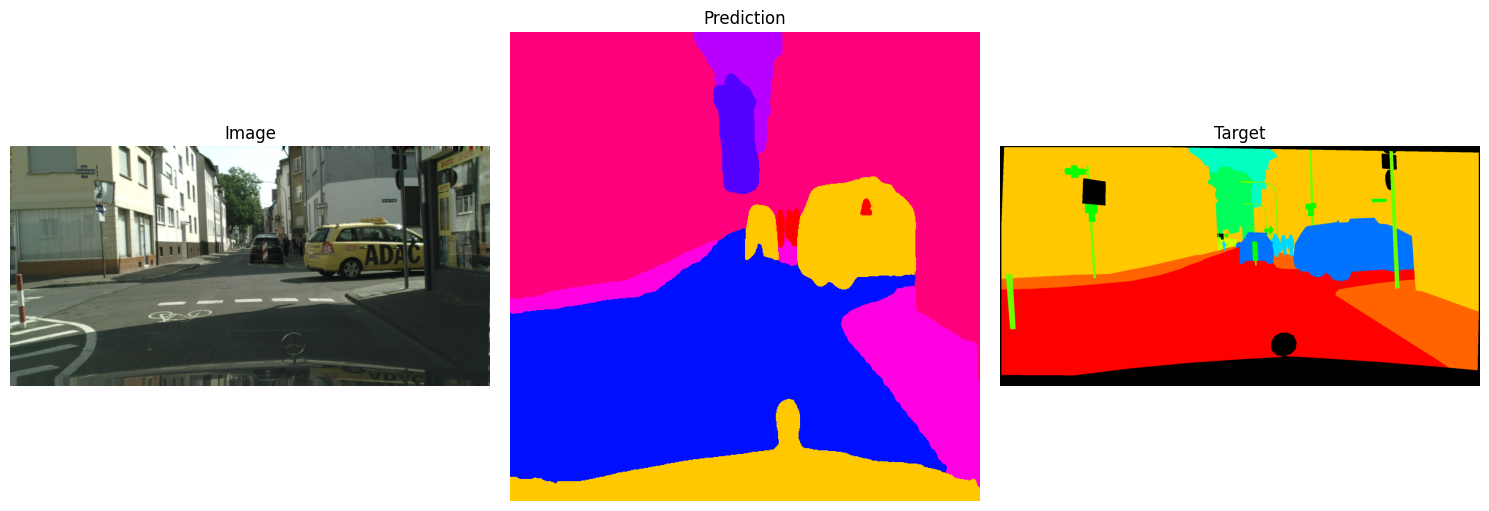

In [ ]:
import torchvision.transforms.functional as TF

IGNORE_INDEX = 255

def infer_semantic(img, target):
    # Ridimensiona l'immagine all'img_size del modello COCO
    img_resized = TF.resize(img, IMG_SIZE_COCO)

    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img_resized.to(device)]
        img_sizes = [img_resized.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], IMG_SIZE_COCO, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[0].numpy()
    return pred_array, target_array


img, target = data.val_dataloader().dataset[img_idx]
pred_array, target_array = infer_semantic(img, target)
plot_semantic_results(img, pred_array, target_array)

In [ ]:
IGNORE_INDEX = 255


def infer_semantic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data.img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]
pred_array, target_array = infer_semantic(img, target)
plot_semantic_results(img, pred_array, target_array)

RuntimeError: The size of tensor a (640) must match the size of tensor b (1024) at non-singleton dimension 2

## Panoptic inference (segmentation with instance IDs)

> This inference method also works when applied to a model trained for instance segmentation.

Panoptic inference assigns each pixel $[h, w]$ to the query $i$ that maximizes the product of class and mask confidence:

$$
p_i(c_i) \cdot m_i[h, w]
$$

where $c_i = \arg\max_c \, p_i(c)$ is the most likely class for query $i$. A pixel is assigned to a query only if both the class confidence and mask confidence are high. Pixels assigned to the same query form a segment labeled with $c_i$. "Stuff" segments with the same class are merged; "thing" segments are kept distinct using the query index. Low-confidence and heavily occluded predictions are filtered out.  
  
*This inference method was originally introduced in MaskFormer.*

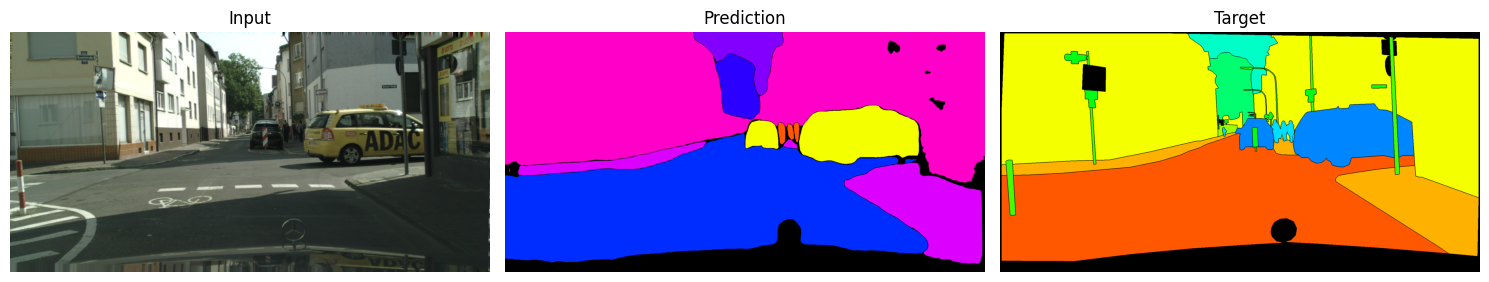

In [ ]:
def infer_panoptic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model.img_size, mode="bilinear"
        )
        mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model.stuff_classes,
            model.mask_thresh,
            model.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    target_seg = model.to_per_pixel_targets_panoptic([target])[0].cpu().numpy()
    sem_target, inst_target = target_seg[..., 0], target_seg[..., 1]

    return sem_pred, inst_pred, sem_target, inst_target


def draw_black_border(sem, inst, mapping):
    h, w = sem.shape
    out = np.zeros((h, w, 3))
    for s in np.unique(sem):
        out[sem == s] = mapping[s]

    combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    out[border] = 0
    return out


def plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target):
    all_ids = np.union1d(np.unique(sem_pred), np.unique(sem_target))
    mapping = {
        s: (
            [0, 0, 0]
            if s == -1 or s == model.num_classes
            else plt.cm.hsv(i / len(all_ids))[:3]
        )
        for i, s in enumerate(all_ids)
    }

    vis_pred = draw_black_border(sem_pred, inst_pred, mapping)
    vis_target = draw_black_border(sem_target, inst_target, mapping)

    img_np = (
        img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title("Prediction")
    axes[2].imshow(vis_target)
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]
sem_pred, inst_pred, sem_target, inst_target = infer_panoptic(img, target)
plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target)

ORA FACCIAMO LA PARTE DEL main.py

In [ ]:
!python3 main.py validate \
  -c configs/dinov2/cityscapes/semantic/eomt_base_640.yaml \
  --model.network.masked_attn_enabled False \
  --trainer.devices 1 \
  --data.batch_size 1 \
  --data.path /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main \
  --model.ckpt_path /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/trained_models/eomt_cityscapes.bin

2026-05-20 13:58:11.730851: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Seed set to 0
INFO:root:Loaded 197 keys
Using 16bit Automatic Mixed Precision (AMP)
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 3
wandb: You chose "Don't visualize my results"
wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id a1g9up7j.
wandb: Tracking run

In [ ]:
%%writefile ../step4_eval.py
"""
Step 4 - EoMT mIoU Evaluation on Cityscapes val
Evaluates BOTH models on semantic segmentation (mIoU) using 19 Cityscapes classes.
For EoMT-COCO: predictions are remapped via COCO->Cityscapes class mapping.
Same evaluation pipeline for both models.
"""

import argparse
import importlib
import warnings
import time
import yaml
import torch
import torch.nn.functional as F
from torch.amp.autocast_mode import autocast
import numpy as np
from lightning import seed_everything

seed_everything(0, verbose=False)
warnings.filterwarnings("ignore", message=r".*Attribute 'network'.*")

CS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic light", "traffic sign", "vegetation", "terrain", "sky",
    "person", "rider", "car", "truck", "bus", "train", "motorcycle", "bicycle"
]
NUM_CS_CLASSES = 19
IGNORE_INDEX = 255

COCO_NAMES = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train",
    "truck", "boat", "traffic light", "fire hydrant", "stop sign",
    "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag",
    "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite",
    "baseball bat", "baseball glove", "skateboard", "surfboard",
    "tennis racket", "bottle", "wine glass", "cup", "fork", "knife", "spoon",
    "bowl", "banana", "apple", "sandwich", "orange", "broccoli", "carrot",
    "hot dog", "pizza", "donut", "cake", "chair", "couch", "potted plant",
    "bed", "dining table", "toilet", "tv", "laptop", "mouse", "remote",
    "keyboard", "cell phone", "microwave", "oven", "toaster", "sink",
    "refrigerator", "book", "clock", "vase", "scissors", "teddy bear",
    "hair drier", "toothbrush", "banner", "blanket", "bridge", "cardboard",
    "counter", "curtain", "door-stuff", "floor-wood", "flower", "fruit",
    "gravel", "house", "light", "mirror-stuff", "net", "pillow", "platform",
    "playingfield", "railroad", "river", "road", "roof", "sand", "sea",
    "shelf", "snow", "stairs", "tent", "towel", "wall-brick", "wall-stone",
    "wall-tile", "wall-wood", "water-other", "window-blind", "window-other",
    "tree-merged", "fence-merged", "ceiling-merged", "sky-other-merged",
    "cabinet-merged", "table-merged", "floor-other-merged", "pavement-merged",
    "mountain-merged", "grass-merged", "dirt-merged", "paper-merged",
    "food-other-merged", "building-other-merged", "rock-merged",
    "wall-other-merged", "rug-merged",
]

_COCO_NAME_TO_CS_ID = {
    "person":                11,
    "bicycle":               18,
    "car":                   13,
    "motorcycle":            17,
    "bus":                   15,
    "train":                 16,
    "truck":                 14,
    "traffic light":          6,
    "road":                   0,
    "railroad":               0,
    "pavement-merged":        1,
    "building-other-merged":  2,
    "house":                  2,
    "fence-merged":           4,
    "tree-merged":            8,
    "grass-merged":           9,
    "sky-other-merged":      10,
    "wall-brick":             3,
    "wall-stone":             3,
    "wall-tile":              3,
    "wall-wood":              3,
    "wall-other-merged":      3,
    "stop sign":              7,
}

def build_coco_to_cs_lut(coco_names):
    lut = np.full(len(coco_names) + 1, IGNORE_INDEX, dtype=np.int64)
    for coco_id, name in enumerate(coco_names):
        cs_id = _COCO_NAME_TO_CS_ID.get(name, None)
        if cs_id is not None:
            lut[coco_id] = cs_id
    return lut


class IoUEvaluator:
    def __init__(self, num_classes, ignore_index=255):
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.tp = np.zeros(num_classes, dtype=np.float64)
        self.fp = np.zeros(num_classes, dtype=np.float64)
        self.fn = np.zeros(num_classes, dtype=np.float64)

    def update(self, pred, target):
        mask = target != self.ignore_index
        pred = pred[mask]
        target = target[mask]
        for c in range(self.num_classes):
            p = pred == c
            t = target == c
            self.tp[c] += (p & t).sum()
            self.fp[c] += (p & ~t).sum()
            self.fn[c] += (~p & t).sum()

    def iou_per_class(self):
        denom = self.tp + self.fp + self.fn
        return np.where(denom > 0, self.tp / denom, np.nan)

    def miou(self):
        return float(np.nanmean(self.iou_per_class()))


def load_model(config_path, ckpt_path, img_size, num_classes, stuff_classes=None, device=0):
    with open(config_path) as f:
        config = yaml.safe_load(f)

    enc_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    enc_cls = getattr(importlib.import_module(enc_cfg["class_path"].rsplit(".", 1)[0]),
                      enc_cfg["class_path"].rsplit(".", 1)[1])
    encoder = enc_cls(img_size=img_size, **enc_cfg.get("init_args", {}))

    net_cfg = config["model"]["init_args"]["network"]
    net_cls = getattr(importlib.import_module(net_cfg["class_path"].rsplit(".", 1)[0]),
                      net_cfg["class_path"].rsplit(".", 1)[1])
    net_kwargs = {k: v for k, v in net_cfg["init_args"].items() if k != "encoder"}
    network = net_cls(masked_attn_enabled=False, num_classes=num_classes,
                      encoder=encoder, **net_kwargs)

    lit_cfg = config["model"]
    lit_cls = getattr(importlib.import_module(lit_cfg["class_path"].rsplit(".", 1)[0]),
                      lit_cfg["class_path"].rsplit(".", 1)[1])
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
    if stuff_classes is not None:
        model_kwargs["stuff_classes"] = stuff_classes

    model = lit_cls(img_size=img_size, num_classes=num_classes,
                    network=network, **model_kwargs).eval().to(device)
    state_dict = torch.load(ckpt_path, map_location=f"cuda:{device}", weights_only=True)
    model.load_state_dict(state_dict, strict=False)
    return model


@torch.no_grad()
def infer_semantic(model, img, device):
    imgs = [img.to(device)]
    img_sizes = [img.shape[-2:] for img in imgs]
    with autocast(dtype=torch.float16, device_type="cuda"):
        crops, origins = model.window_imgs_semantic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(mask_logits_per_layer[-1], model.img_size, mode="bilinear")
        crop_logits = model.to_per_pixel_logits_semantic(mask_logits, class_logits_per_layer[-1])
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
    return logits[0].float().cpu()


def evaluate_model(model, val_dataset, device, coco_lut=None, model_name="model"):
    evaluator = IoUEvaluator(NUM_CS_CLASSES, IGNORE_INDEX)
    t0 = time.time()
    for step, (img, target) in enumerate(val_dataset):
        gt = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[0].numpy()
        logits = infer_semantic(model, img, device)
        pred = logits.argmax(0).numpy()
        if coco_lut is not None:
            pred = coco_lut[pred]
        if pred.shape != gt.shape:
            pred_t = torch.from_numpy(pred).unsqueeze(0).unsqueeze(0).float()
            pred = F.interpolate(pred_t, size=gt.shape, mode="nearest").squeeze().numpy().astype(np.int64)
        evaluator.update(pred, gt)
        if (step + 1) % 50 == 0:
            print(f"  [{model_name}] {step+1}/500  mIoU: {evaluator.miou()*100:.1f}%  ({time.time()-t0:.0f}s)")
    return evaluator


def print_results(eval_cs, eval_coco):
    iou_cs = eval_cs.iou_per_class()
    iou_coco = eval_coco.iou_per_class()
    header = f"{'Class':<25}  {'EoMT-CS':>10}  {'EoMT-COCO':>10}"
    sep = "-" * len(header)
    print("\n" + sep)
    print(header)
    print(sep)
    for i, name in enumerate(CS_NAMES):
        cs_str   = f"{iou_cs[i]*100:6.2f}%"   if not np.isnan(iou_cs[i])   else "   N/A  "
        coco_str = f"{iou_coco[i]*100:6.2f}%" if not np.isnan(iou_coco[i]) else "   N/A  "
        print(f"{name:<25}  {cs_str:>10}  {coco_str:>10}")
    print(sep)
    print(f"{'mIoU':<25}  {eval_cs.miou()*100:>9.2f}%  {eval_coco.miou()*100:>9.2f}%")
    print(sep)


def main(args):
    device = args.device

    print("[1/5] Loading Cityscapes val dataset...")
    with open(args.cityscapes_config) as f:
        cs_config = yaml.safe_load(f)
    dm_name, dm_cls_name = cs_config["data"]["class_path"].rsplit(".", 1)
    dm_cls = getattr(importlib.import_module(dm_name), dm_cls_name)
    dm_kwargs = cs_config["data"].get("init_args", {})
    cs_data = dm_cls(path=args.data_path, batch_size=1, num_workers=0,
                     check_empty_targets=False, **dm_kwargs).setup()
    val_dataset = cs_data.val_dataloader().dataset
    print(f"  {len(val_dataset)} images")

    print("\n[2/5] Loading EoMT-Cityscapes...")
    cs_model = load_model(args.cityscapes_config, args.cityscapes_ckpt,
                          cs_data.img_size, cs_data.num_classes, device=device)

    print("\n[3/5] Loading EoMT-COCO...")
    with open(args.coco_config) as f:
        coco_config = yaml.safe_load(f)
    stuff_classes = coco_config["data"]["init_args"].get("stuff_classes", None)
    coco_model = load_model(args.coco_config, args.coco_ckpt,
                            [640, 640], 133,
                            stuff_classes=stuff_classes, device=device)

    print("\n[4/5] Building COCO->Cityscapes mapping...")
    coco_lut = build_coco_to_cs_lut(COCO_NAMES)
    mapped = [(i, COCO_NAMES[i], coco_lut[i]) for i in range(len(COCO_NAMES)) if coco_lut[i] != IGNORE_INDEX]
    print(f"  {len(mapped)} COCO classes mapped to Cityscapes, {len(COCO_NAMES)-len(mapped)} ignored")

    print("\n[5/5] Evaluating...")
    print("\n  --- EoMT-Cityscapes ---")
    eval_cs = evaluate_model(cs_model, val_dataset, device, coco_lut=None, model_name="EoMT-CS")
    print("\n  --- EoMT-COCO ---")
    eval_coco = evaluate_model(coco_model, val_dataset, device, coco_lut=coco_lut, model_name="EoMT-COCO")

    print_results(eval_cs, eval_coco)

    if args.output_file:
        import sys
        orig = sys.stdout
        with open(args.output_file, "w") as f:
            sys.stdout = f
            print_results(eval_cs, eval_coco)
        sys.stdout = orig
        print(f"\nResults saved to: {args.output_file}")


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--cityscapes-config", required=True)
    parser.add_argument("--cityscapes-ckpt",   required=True)
    parser.add_argument("--coco-config",       required=True)
    parser.add_argument("--coco-ckpt",         required=True)
    parser.add_argument("--data-path",         required=True)
    parser.add_argument("--device",            type=int, default=0)
    parser.add_argument("--output-file",       default=None)
    main(parser.parse_args())

Writing ../step4_eval.py


In [ ]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/eomt')

In [ ]:
with open('../step4_eval.py', 'r') as f:
    content = f.read()

content = content.replace(
    'from lightning import seed_everything',
    'import sys\nsys.path.insert(0, "/content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/eomt")\nfrom lightning import seed_everything'
)

with open('../step4_eval.py', 'w') as f:
    f.write(content)

print("Fatto!")

Fatto!


In [ ]:
!python3 ../step4_eval.py \
    --cityscapes-config configs/dinov2/cityscapes/semantic/eomt_base_640.yaml \
    --cityscapes-ckpt /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/trained_models/eomt_cityscapes.bin \
    --coco-config configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml \
    --coco-ckpt /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/trained_models/eomt_coco.bin \
    --data-path /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main \
    --output-file ../step4_results.txt

[1/5] Loading Cityscapes val dataset...
  500 images

[2/5] Loading EoMT-Cityscapes...
2026-05-20 14:09:17.834199: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

[3/5] Loading EoMT-COCO...

[4/5] Building COCO->Cityscapes mapping...
  23 COCO classes mapped to Cityscapes, 110 ignored

[5/5] Evaluating...

  --- EoMT-Cityscapes ---
  [EoMT-CS] 50/500  mIoU: 80.6%  (70s)
  [EoMT-CS] 100/500  mIoU: 81.2%  (141s)
  [EoMT-CS] 150/500  mIoU: 81.2%  (214s)
  [EoMT-CS] 200/500  mIoU: 81.0%  (287s)
  [EoMT-CS] 250/500  mIoU: 80.6%  (359s)
  [EoMT-CS] 300/500  mIoU: 81.1%  (431s)
  [EoMT-CS] 350/500  mIoU: 81.0%  (500s)
  [EoMT-CS] 400/500  mIoU: 81.2%  (571s)
  [EoMT-CS] 450/500  mIoU: 81.3%  (642s)
  [EoMT-CS] 500/500  mIoU: 81.7%  (714s)

  --- EoMT-C

**Step 5 - Fine-Tuning**

Head = class_head + mask_head (2% del totale)

In [ ]:
!python3 main.py fit \
  -c configs/dinov2/cityscapes/semantic/eomt_base_640.yaml \
  --model.ckpt_path /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/trained_models/eomt_coco.bin \
  --model.load_ckpt_class_head False \
  --model.lr_mult 0.0 \
  --model.network.init_args.num_q 200 \
  --data.img_size [640,640] \
  --trainer.devices 1 \
  --trainer.max_epochs 5 \
  --data.batch_size 4 \
  --data.path /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main \
  --compile_disabled

2026-05-27 10:36:12.704439: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-27 10:36:12.773278: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Seed set to 0
INFO:root:Loaded 195 keys
Using 16bit Automatic Mixed Precision (AMP)
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: WARNING T

- solo class_head + mask_head → 78.35%
- class_head + mask_head + upscale + q.weight → ~74% con overfitting

Il problema è che upscale (4.7M params) e q.weight (153K params) sono layer importanti del decoder — sbloccarli insieme alla head con pochi epoch causa instabilità e overfitting.
Nel nostro approccio con lr_mult=0.0 questi layer vengono lasciati con LR=0, quindi non vengono aggiornati. Abbiamo una fine-tuning più conservativa, interessante per il report

In [ ]:
!find . -name "*.ckpt" | head -10

./eomt/yysfpk6x/checkpoints/epoch=4-step=3715.ckpt


In [ ]:
!cp ./eomt/yysfpk6x/checkpoints/epoch=4-step=3715.ckpt \
    /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/trained_models/eomt_finetuned.ckpt

In [ ]:
%%writefile ../step5_eval.py
"""
Step 5 - Fine-tuned EoMT vs EoMT-Cityscapes evaluation
Compares:
  - EoMT-Cityscapes (original, provided by prof)
  - EoMT-Finetuned (COCO model fine-tuned on Cityscapes)
Same evaluation pipeline as step4_eval.py.
"""

import sys
sys.path.insert(0, '/content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/eomt')

import argparse
import importlib
import warnings
import time
import yaml
import torch
import torch.nn.functional as F
from torch.amp.autocast_mode import autocast
import numpy as np
from lightning import seed_everything

seed_everything(0, verbose=False)
warnings.filterwarnings("ignore", message=r".*Attribute 'network'.*")

CS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic light", "traffic sign", "vegetation", "terrain", "sky",
    "person", "rider", "car", "truck", "bus", "train", "motorcycle", "bicycle"
]
NUM_CS_CLASSES = 19
IGNORE_INDEX = 255


class IoUEvaluator:
    def __init__(self, num_classes, ignore_index=255):
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.tp = np.zeros(num_classes, dtype=np.float64)
        self.fp = np.zeros(num_classes, dtype=np.float64)
        self.fn = np.zeros(num_classes, dtype=np.float64)

    def update(self, pred, target):
        mask = target != self.ignore_index
        pred = pred[mask]
        target = target[mask]
        for c in range(self.num_classes):
            p = pred == c
            t = target == c
            self.tp[c] += (p & t).sum()
            self.fp[c] += (p & ~t).sum()
            self.fn[c] += (~p & t).sum()

    def iou_per_class(self):
        denom = self.tp + self.fp + self.fn
        return np.where(denom > 0, self.tp / denom, np.nan)

    def miou(self):
        return float(np.nanmean(self.iou_per_class()))


def load_model(config_path, ckpt_path, img_size, num_classes, device=0):
    with open(config_path) as f:
        config = yaml.safe_load(f)

    enc_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    enc_cls = getattr(importlib.import_module(enc_cfg["class_path"].rsplit(".", 1)[0]),
                      enc_cfg["class_path"].rsplit(".", 1)[1])
    encoder = enc_cls(img_size=img_size, **enc_cfg.get("init_args", {}))

    net_cfg = config["model"]["init_args"]["network"]
    net_cls = getattr(importlib.import_module(net_cfg["class_path"].rsplit(".", 1)[0]),
                      net_cfg["class_path"].rsplit(".", 1)[1])
    net_kwargs = {k: v for k, v in net_cfg["init_args"].items() if k != "encoder"}
    network = net_cls(masked_attn_enabled=False, num_classes=num_classes,
                      encoder=encoder, **net_kwargs)

    lit_cfg = config["model"]
    lit_cls = getattr(importlib.import_module(lit_cfg["class_path"].rsplit(".", 1)[0]),
                      lit_cfg["class_path"].rsplit(".", 1)[1])
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}

    model = lit_cls(img_size=img_size, num_classes=num_classes,
                    network=network, **model_kwargs).eval().to(device)

    # Support both .bin and .ckpt checkpoints
    state_dict = torch.load(ckpt_path, map_location=f"cuda:{device}", weights_only=True)
    if "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]
    model.load_state_dict(state_dict, strict=False)
    return model


@torch.no_grad()
def infer_semantic(model, img, device):
    imgs = [img.to(device)]
    img_sizes = [img.shape[-2:] for img in imgs]
    with autocast(dtype=torch.float16, device_type="cuda"):
        crops, origins = model.window_imgs_semantic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(mask_logits_per_layer[-1], model.img_size, mode="bilinear")
        crop_logits = model.to_per_pixel_logits_semantic(mask_logits, class_logits_per_layer[-1])
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
    return logits[0].float().cpu()


def evaluate_model(model, val_dataset, device, model_name="model"):
    evaluator = IoUEvaluator(NUM_CS_CLASSES, IGNORE_INDEX)
    t0 = time.time()
    for step, (img, target) in enumerate(val_dataset):
        gt = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[0].numpy()
        logits = infer_semantic(model, img, device)
        pred = logits.argmax(0).numpy()
        if pred.shape != gt.shape:
            pred_t = torch.from_numpy(pred).unsqueeze(0).unsqueeze(0).float()
            pred = F.interpolate(pred_t, size=gt.shape, mode="nearest").squeeze().numpy().astype(np.int64)
        evaluator.update(pred, gt)
        if (step + 1) % 50 == 0:
            print(f"  [{model_name}] {step+1}/500  mIoU: {evaluator.miou()*100:.1f}%  ({time.time()-t0:.0f}s)")
    return evaluator


def print_results(eval_cs, eval_ft):
    iou_cs = eval_cs.iou_per_class()
    iou_ft = eval_ft.iou_per_class()
    header = f"{'Class':<25}  {'EoMT-CS':>10}  {'EoMT-Finetuned':>14}"
    sep = "-" * len(header)
    print("\n" + sep)
    print(header)
    print(sep)
    for i, name in enumerate(CS_NAMES):
        cs_str = f"{iou_cs[i]*100:6.2f}%" if not np.isnan(iou_cs[i]) else "   N/A  "
        ft_str = f"{iou_ft[i]*100:6.2f}%" if not np.isnan(iou_ft[i]) else "   N/A  "
        print(f"{name:<25}  {cs_str:>10}  {ft_str:>14}")
    print(sep)
    print(f"{'mIoU':<25}  {eval_cs.miou()*100:>9.2f}%  {eval_ft.miou()*100:>13.2f}%")
    print(sep)


def main(args):
    device = args.device

    print("[1/4] Loading Cityscapes val dataset...")
    with open(args.config) as f:
        cs_config = yaml.safe_load(f)
    dm_name, dm_cls_name = cs_config["data"]["class_path"].rsplit(".", 1)
    dm_cls = getattr(importlib.import_module(dm_name), dm_cls_name)
    dm_kwargs = cs_config["data"].get("init_args", {})
    cs_data = dm_cls(path=args.data_path, batch_size=1, num_workers=0,
                     check_empty_targets=False, **dm_kwargs).setup()
    val_dataset = cs_data.val_dataloader().dataset
    print(f"  {len(val_dataset)} images")

    print("\n[2/4] Loading EoMT-Cityscapes (original)...")
    cs_model = load_model(args.config, args.cityscapes_ckpt,
                          cs_data.img_size, cs_data.num_classes, device=device)

    print("\n[3/4] Loading EoMT-Finetuned...")
    ft_model = load_model(args.config, args.finetuned_ckpt,
                          [640, 640], cs_data.num_classes, device=device)

    print("\n[4/4] Evaluating...")
    print("\n  --- EoMT-Cityscapes (original) ---")
    eval_cs = evaluate_model(cs_model, val_dataset, device, model_name="EoMT-CS")
    print("\n  --- EoMT-Finetuned ---")
    eval_ft = evaluate_model(ft_model, val_dataset, device, model_name="EoMT-FT")

    print_results(eval_cs, eval_ft)

    if args.output_file:
        import sys as _sys
        orig = _sys.stdout
        with open(args.output_file, "w") as f:
            _sys.stdout = f
            print_results(eval_cs, eval_ft)
        _sys.stdout = orig
        print(f"\nResults saved to: {args.output_file}")


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--config",          required=True, help="Cityscapes semantic config")
    parser.add_argument("--cityscapes-ckpt", required=True, help="EoMT-Cityscapes checkpoint")
    parser.add_argument("--finetuned-ckpt",  required=True, help="EoMT-Finetuned checkpoint")
    parser.add_argument("--data-path",       required=True)
    parser.add_argument("--device",          type=int, default=0)
    parser.add_argument("--output-file",     default=None)
    main(parser.parse_args())

Writing ../step5_eval.py


In [ ]:
!python3 ../step5_eval.py \
    --config configs/dinov2/cityscapes/semantic/eomt_base_640.yaml \
    --cityscapes-ckpt /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/trained_models/eomt_cityscapes.bin \
    --finetuned-ckpt /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/trained_models/eomt_finetuned.ckpt \
    --data-path /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main \
    --output-file ../step5_results.txt

[1/4] Loading Cityscapes val dataset...
  500 images

[2/4] Loading EoMT-Cityscapes (original)...
model.safetensors: 100% 346M/346M [00:02<00:00, 120MB/s]
2026-05-23 18:03:35.926895: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-23 18:03:35.995319: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

[3/4] Loading EoMT-Finetuned...
Traceback (most recent call last):
  File "/content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/eomt/../step5_eval.py", line 188, 

In [ ]:
with open('../step5_eval.py', 'r') as f:
    content = f.read()

content = content.replace(
    '    print("\\n[3/4] Loading EoMT-Finetuned...")\n    ft_model = load_model(args.config, args.finetuned_ckpt,\n                          [640, 640], cs_data.num_classes, device=device)',
    '    print("\\n[3/4] Loading EoMT-Finetuned...")\n    ft_model = load_model(args.config, args.finetuned_ckpt,\n                          [640, 640], cs_data.num_classes, device=device, num_q_override=200)'
)

# Aggiorna anche load_model per supportare num_q_override
content = content.replace(
    'def load_model(config_path, ckpt_path, img_size, num_classes, device=0):',
    'def load_model(config_path, ckpt_path, img_size, num_classes, device=0, num_q_override=None):'
)

content = content.replace(
    '    net_kwargs = {k: v for k, v in net_cfg["init_args"].items() if k != "encoder"}',
    '    net_kwargs = {k: v for k, v in net_cfg["init_args"].items() if k != "encoder"}\n    if num_q_override is not None:\n        net_kwargs["num_q"] = num_q_override'
)

with open('../step5_eval.py', 'w') as f:
    f.write(content)

print("Fatto!")


Fatto!


In [ ]:
!python3 ../step5_eval.py \
    --config configs/dinov2/cityscapes/semantic/eomt_base_640.yaml \
    --cityscapes-ckpt /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/trained_models/eomt_cityscapes.bin \
    --finetuned-ckpt /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/trained_models/eomt_finetuned.ckpt \
    --data-path /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main \
    --output-file ../step5_results.txt

[1/4] Loading Cityscapes val dataset...
  500 images

[2/4] Loading EoMT-Cityscapes (original)...
2026-05-23 18:06:00.871245: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-23 18:06:00.941441: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

[3/4] Loading EoMT-Finetuned...

[4/4] Evaluating...

  --- EoMT-Cityscapes (original) ---
  [EoMT-CS] 50/500  mIoU: 80.6%  (42s)
  [EoMT-CS] 100/500  mIoU: 81.2%  (83s)
  [EoMT-CS] 150/500  mIoU: 81.2%  (125s)
  [EoMT-CS] 200/500  mIoU: 81.0%  (167s)
  [EoMT-CS] 250/500  mI

In [ ]:
!python3 main.py fit \
  -c configs/dinov2/cityscapes/semantic/eomt_base_640.yaml \
  --model.ckpt_path /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main/trained_models/eomt_finetuned.ckpt \
  --model.load_ckpt_class_head True \
  --model.lr_mult 0.1 \
  --model.network.init_args.num_q 200 \
  --data.img_size [640,640] \
  --trainer.devices 1 \
  --trainer.max_epochs 5 \
  --data.batch_size 4 \
  --data.path /content/drive/MyDrive/MaskArchitectureAnomaly_CourseProject-main/MaskArchitectureAnomaly_CourseProject-main \
  --compile_disabled

2026-05-23 18:22:55.287510: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-23 18:22:55.359457: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Seed set to 0
INFO:root:Loaded 197 keys
Using 16bit Automatic Mixed Precision (AMP)
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: (1) Creat

Abbiamo ottenuto overfitting!

NOTA: dovresti scongelare 0.1 alla volta, per ora ci limitiamo ai primi due casi, decideremo in seguito se continuare